### Imports
Libraries for data handling, plotting, preprocessing, modeling and evaluation.

In [ ]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Load Dataset
Read the CSV and check its shape.

In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')
df.shape

(32581, 12)

### Preview Data
Look at the first five rows.

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Dataset Info
Column types and non-null counts.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


### Summary Statistics
Quick statistical summary of every column.

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### Missing Values
Count of missing values per column.

In [ ]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Duplicate Check
Check for exact duplicate rows.

In [ ]:
df.duplicated().sum()

np.int64(165)

### Target Distribution
How loan_amnt is distributed (histogram + boxplot).

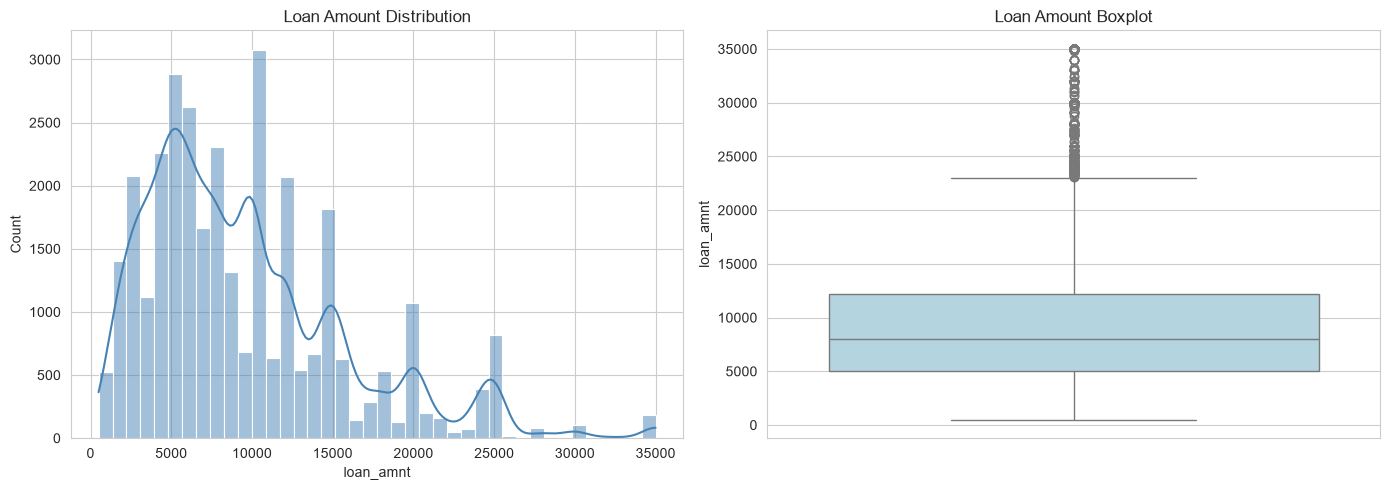

count    32581.000000
mean      9589.371106
std       6322.086646
min        500.000000
25%       5000.000000
50%       8000.000000
75%      12200.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df['loan_amnt'], kde=True, bins=40, color='steelblue')
plt.title('Loan Amount Distribution')

plt.subplot(1,2,2)
sns.boxplot(y=df['loan_amnt'], color='lightblue')
plt.title('Loan Amount Boxplot')

plt.tight_layout()
plt.show()

df['loan_amnt'].describe()

### Feature Distributions
Histograms of the key numeric features.

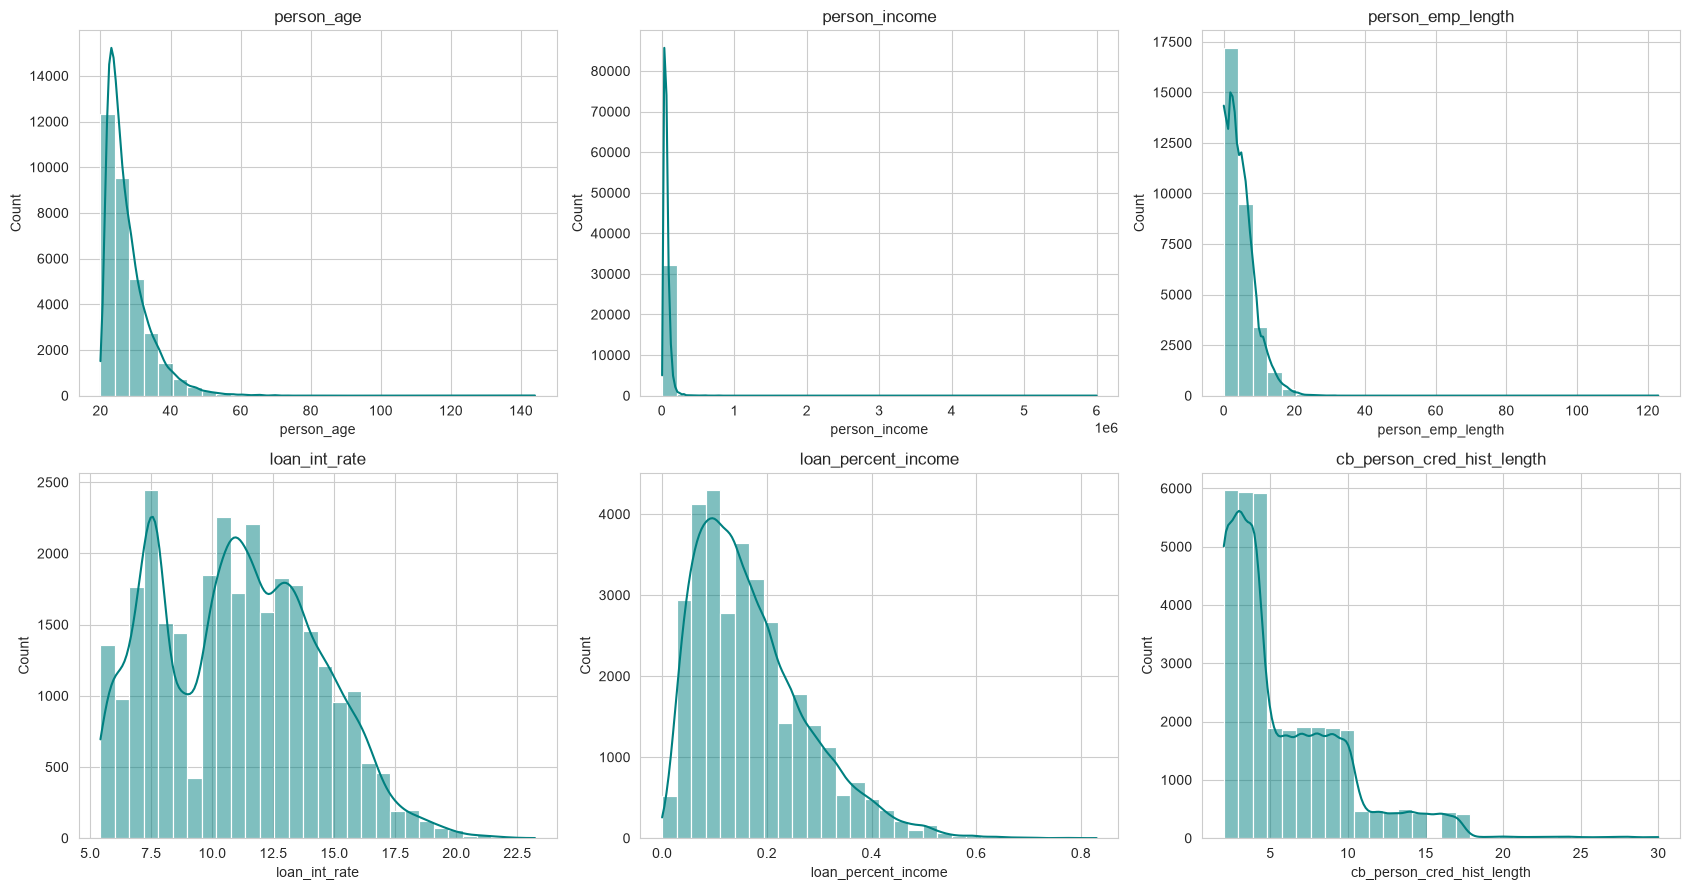

In [ ]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(17,9))
axes = axes.flatten()
for i in range(len(num_cols)):
    sns.histplot(df[num_cols[i]], kde=True, bins=30, ax=axes[i], color='teal')
    axes[i].set_title(num_cols[i])
plt.tight_layout()
plt.show()

### Feature vs Target Scatter Plots
How income, interest rate and loan-percent-income relate to loan amount.

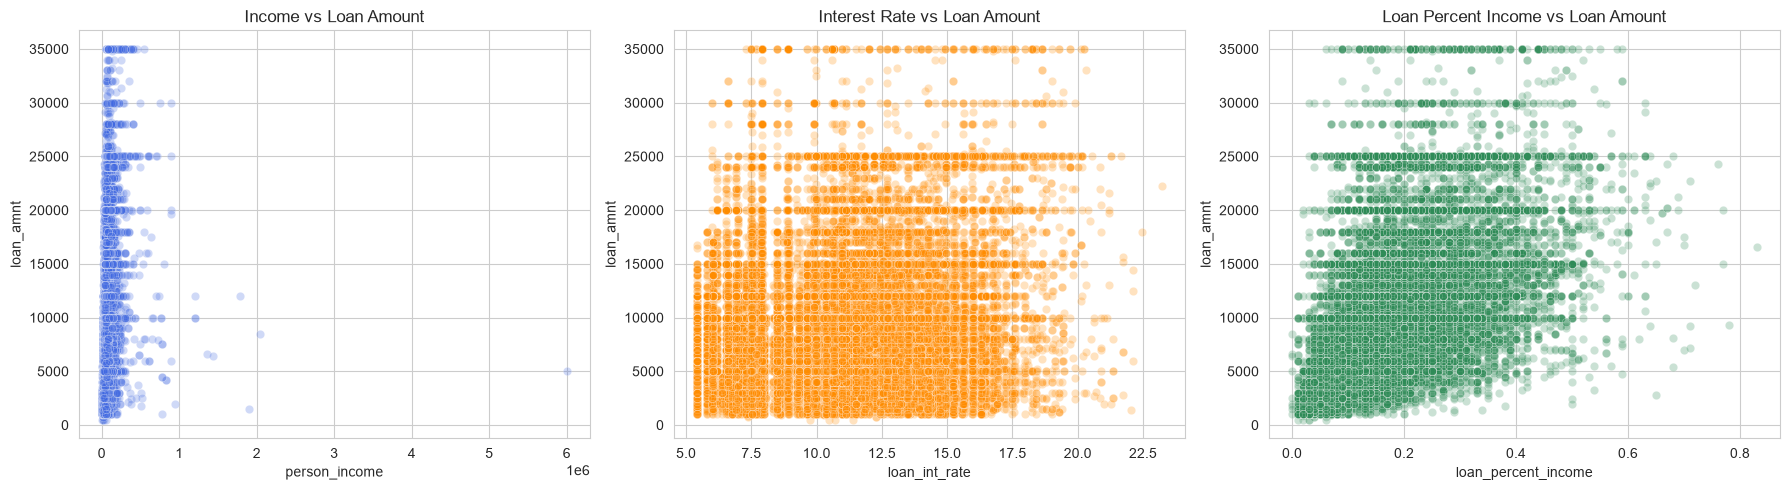

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(x='person_income', y='loan_amnt', data=df, alpha=0.25, ax=axes[0], color='royalblue')
axes[0].set_title('Income vs Loan Amount')

sns.scatterplot(x='loan_int_rate', y='loan_amnt', data=df, alpha=0.25, ax=axes[1], color='darkorange')
axes[1].set_title('Interest Rate vs Loan Amount')

sns.scatterplot(x='loan_percent_income', y='loan_amnt', data=df, alpha=0.25, ax=axes[2], color='seagreen')
axes[2].set_title('Loan Percent Income vs Loan Amount')

plt.tight_layout()
plt.show()

### Correlation Heatmap
Correlation between numeric features and the target.

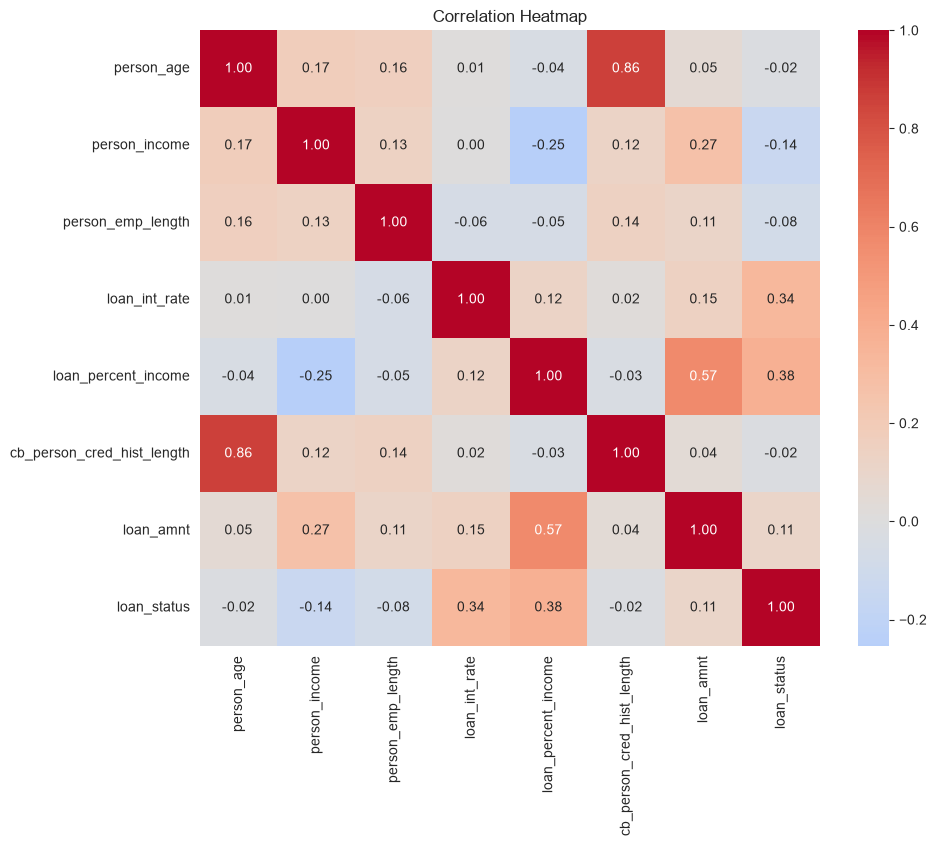

In [ ]:
plt.figure(figsize=(10,8))
corr = df[num_cols + ['loan_amnt', 'loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### Outlier Removal
Drop rows with unrealistic age (>100) or employment length (>60 years).

In [ ]:
print((df['person_age'] > 100).sum(), 'rows with age > 100')
print((df['person_emp_length'] > 60).sum(), 'rows with emp length > 60')

df_clean = df[(df['person_age'] <= 100) &
              (df['person_emp_length'].isna() | (df['person_emp_length'] <= 60))].reset_index(drop=True)

print(df.shape[0], '->', df_clean.shape[0])

5 rows with age > 100
2 rows with emp length > 60
32581 -> 32574


### Feature Groups
Split columns into numeric, ordinal and nominal groups for preprocessing.

In [ ]:
X = df_clean.drop(columns=['loan_amnt'])
y = df_clean['loan_amnt']

num_features = ['person_age', 'person_income', 'person_emp_length', 'loan_int_rate',
                'loan_percent_income', 'loan_status', 'cb_person_cred_hist_length']
ord_features = ['loan_grade']
nom_features = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

### Preprocessing Pipeline
Impute missing values, add degree-2 polynomial features and scale the numeric block; encode the categorical columns.

In [ ]:
# adding degree-2 polynomial/interaction terms on the numeric block so the linear
# models can pick up curvature and interactions (e.g. income * loan_percent_income)
# instead of only straight-line effects. this is what actually moved R2 the most.
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['A','B','C','D','E','F','G']]))
])

nom_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('ord', ord_pipe, ord_features),
    ('nom', nom_pipe, nom_features)
])

### Train / Val / Test Split + Log Target
70/15/15 split, then log1p-transform the skewed target (with a clip helper to invert predictions safely).

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print(X_train.shape, X_val.shape, X_test.shape)

# We define functions to compute percentage-based metrics: MAPE, Relative MAE, and Relative MSE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def relative_mae_pct(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred) / np.mean(y_true)) * 100

def relative_mse_pct(y_true, y_pred):
    return (mean_squared_error(y_true, y_pred) / (np.mean(y_true) ** 2)) * 100

(22801, 11) (4886, 11) (4887, 11)


### Linear Regression (baseline)
Plain linear regression, no regularization — the reference model.

In [ ]:
lr_model = TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler())
lr_pipe = Pipeline([('prep', preprocessor), ('model', lr_model)])

t0 = time.time()
lr_pipe.fit(X_train, y_train)
lr_time = time.time() - t0

lr_cv = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='r2').mean()

y_train_pred_lr = lr_pipe.predict(X_train)
y_val_pred_lr = lr_pipe.predict(X_val)
y_test_pred_lr = lr_pipe.predict(X_test)

lr_train_r2 = r2_score(y_train, y_train_pred_lr)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

lr_val_mae = mean_absolute_error(y_val, y_val_pred_lr)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
lr_val_r2 = r2_score(y_val, y_val_pred_lr)

lr_test_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
lr_test_r2 = r2_score(y_test, y_test_pred_lr)

print('time:', lr_time, 'cv r2:', lr_cv)
print('val  ->', lr_val_mae, lr_val_rmse, lr_val_r2)
print('test ->', lr_test_mae, lr_test_rmse, lr_test_r2)

time: 0.21545195579528809 cv r2: 0.9966258594688556
val  -> 204.24901048456329 380.51886435804806 0.9964267292533875
test -> 209.54109301845702 422.9152109898897 0.9954193765376279


### Ridge Regression
L2-regularized regression, alpha tuned with GridSearchCV (5-fold).

In [ ]:
ridge_model = TransformedTargetRegressor(regressor=Ridge(random_state=RANDOM_STATE), transformer=StandardScaler())
ridge_pipe = Pipeline([('prep', preprocessor), ('model', ridge_model)])
# Using the hyperparameter search space from instructions: Ridge alpha in {0.01, 0.1, 1, 10, 100}
ridge_params = {'model__regressor__alpha': [0.01, 0.1, 1, 10, 100]}

t0 = time.time()
ridge_gs = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
ridge_time = time.time() - t0

ridge_best = ridge_gs.best_estimator_

y_train_pred_ridge = ridge_best.predict(X_train)
y_val_pred_ridge = ridge_best.predict(X_val)
y_test_pred_ridge = ridge_best.predict(X_test)

ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))

ridge_val_mae = mean_absolute_error(y_val, y_val_pred_ridge)
ridge_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
ridge_val_r2 = r2_score(y_val, y_val_pred_ridge)

ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

print('best alpha:', ridge_gs.best_params_, 'cv r2:', ridge_gs.best_score_, 'time:', ridge_time)
print('val  ->', ridge_val_mae, ridge_val_rmse, ridge_val_r2)
print('test ->', ridge_test_mae, ridge_test_rmse, ridge_test_r2)

best alpha: {'model__regressor__alpha': 1} cv r2: 0.996626144923568 time: 11.483729839324951
val  -> 204.22116215152332 380.5203304704614 0.9964267017182128
test -> 209.5263791782274 423.0430167643319 0.9954166075731978


### Lasso Regression
L1-regularized regression, alpha tuned with GridSearchCV; also checks how many coefficients get zeroed out.

In [ ]:
lasso_model = TransformedTargetRegressor(regressor=Lasso(random_state=RANDOM_STATE, max_iter=2000), transformer=StandardScaler())
lasso_pipe = Pipeline([('prep', preprocessor), ('model', lasso_model)])
# Using the hyperparameter search space from instructions: Lasso alpha in {0.001, 0.01, 0.1, 1, 10}
lasso_params = {'model__regressor__alpha': [0.001, 0.01, 0.1, 1, 10]}

t0 = time.time()
lasso_gs = GridSearchCV(lasso_pipe, lasso_params, cv=5, scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train, y_train)
lasso_time = time.time() - t0

lasso_best = lasso_gs.best_estimator_

y_train_pred_lasso = lasso_best.predict(X_train)
y_val_pred_lasso = lasso_best.predict(X_val)
y_test_pred_lasso = lasso_best.predict(X_test)

lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))

lasso_val_mae = mean_absolute_error(y_val, y_val_pred_lasso)
lasso_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
lasso_val_r2 = r2_score(y_val, y_val_pred_lasso)

lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)

print('best alpha:', lasso_gs.best_params_, 'cv r2:', lasso_gs.best_score_, 'time:', lasso_time)
print('val  ->', lasso_val_mae, lasso_val_rmse, lasso_val_r2)
print('test ->', lasso_test_mae, lasso_test_rmse, lasso_test_r2)

lasso_coefs = lasso_best.named_steps['model'].regressor_.coef_
print('zero coeffs:', (np.abs(lasso_coefs) < 1e-8).sum(), '/', len(lasso_coefs))

best alpha: {'model__regressor__alpha': 0.001} cv r2: 0.9966796260471726 time: 2.5956032276153564
val  -> 198.49434961420786 379.3801000722735 0.9964480844331194
test -> 204.02550903817283 419.49041217007124 0.9954932646044816
zero coeffs: 34 / 45


### Elastic Net
Combines L1 + L2 penalties; alpha and l1_ratio tuned together with GridSearchCV.

In [ ]:
en_model = TransformedTargetRegressor(regressor=ElasticNet(random_state=RANDOM_STATE, max_iter=2000), transformer=StandardScaler())
en_pipe = Pipeline([('prep', preprocessor), ('model', en_model)])
# Using hyperparameter search space from instructions: Elastic Net alpha in {0.01, 0.1, 1, 10}, l1_ratio in {0.2, 0.5, 0.8}
en_params = {
    'model__regressor__alpha': [0.01, 0.1, 1, 10],
    'model__regressor__l1_ratio': [0.2, 0.5, 0.8]
}

t0 = time.time()
en_gs = GridSearchCV(en_pipe, en_params, cv=5, scoring='r2', n_jobs=-1)
en_gs.fit(X_train, y_train)
en_time = time.time() - t0

en_best = en_gs.best_estimator_

y_train_pred_en = en_best.predict(X_train)
y_val_pred_en = en_best.predict(X_val)
y_test_pred_en = en_best.predict(X_test)

en_train_r2 = r2_score(y_train, y_train_pred_en)
en_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_en))

en_val_mae = mean_absolute_error(y_val, y_val_pred_en)
en_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_en))
en_val_r2 = r2_score(y_val, y_val_pred_en)

en_test_mae = mean_absolute_error(y_test, y_test_pred_en)
en_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_en))
en_test_r2 = r2_score(y_test, y_test_pred_en)

print('best params:', en_gs.best_params_, 'cv r2:', en_gs.best_score_, 'time:', en_time)
print('val  ->', en_val_mae, en_val_rmse, en_val_r2)
print('test ->', en_test_mae, en_test_rmse, en_test_r2)

best params: {'model__regressor__alpha': 0.01, 'model__regressor__l1_ratio': 0.5} cv r2: 0.9965230128581576 time: 22.913472890853882
val  -> 199.8105374237844 386.7685855134483 0.996308389059749
test -> 204.75929874756295 420.9115684647728 0.9954626768995437


### Table 1 — Hyperparameter Summary
Best parameters and best cross-validated R2 for every model.

In [ ]:
table1 = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net'],
    'Search Method': ['-', 'GridSearchCV', 'GridSearchCV', 'GridSearchCV'],
    'Best Params': ['-', ridge_gs.best_params_, lasso_gs.best_params_, en_gs.best_params_],
    'Best CV R2': [round(lr_cv,4), round(ridge_gs.best_score_,4), round(lasso_gs.best_score_,4), round(en_gs.best_score_,4)]
})
table1

,Model,Search Method,Best Params,Best CV R2
0,Linear Regression,-,-,0.9966
1,Ridge Regression,GridSearchCV,{'model__regressor__alpha': 1},0.9966
2,Lasso Regression,GridSearchCV,{'model__regressor__alpha': 0.001},0.9967
3,Elastic Net,GridSearchCV,"{'model__regressor__alpha': 0.01, 'model__regr...",0.9965


### Table 2 — Validation Performance
MAE, MSE, RMSE, R2 for every model on the validation set.

In [ ]:
table2 = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net'],
    'MAE ($)': [lr_val_mae, ridge_val_mae, lasso_val_mae, en_val_mae],
    'MSE ($^2$)': [lr_val_rmse**2, ridge_val_rmse**2, lasso_val_rmse**2, en_val_rmse**2],
    'RMSE ($)': [lr_val_rmse, ridge_val_rmse, lasso_val_rmse, en_val_rmse],
    'R2': [lr_val_r2, ridge_val_r2, lasso_val_r2, en_val_r2],
    
    'Rel MAE (%)': [
        relative_mae_pct(y_val, y_val_pred_lr),
        relative_mae_pct(y_val, y_val_pred_ridge),
        relative_mae_pct(y_val, y_val_pred_lasso),
        relative_mae_pct(y_val, y_val_pred_en)
    ],
    'Rel MSE (%)': [
        relative_mse_pct(y_val, y_val_pred_lr),
        relative_mse_pct(y_val, y_val_pred_ridge),
        relative_mse_pct(y_val, y_val_pred_lasso),
        relative_mse_pct(y_val, y_val_pred_en)
    ]
}).round(4)
table2

,Model,MAE ($),MSE ($^2$),RMSE ($),R2,Rel MAE (%),Rel MSE (%)
0,Linear Regression,204.2490,144794.6061,380.5189,0.9964,2.1265,0.1569
1,Ridge Regression,204.2212,144795.7219,380.5203,0.9964,2.1262,0.1569
2,Lasso Regression,198.4943,143929.2603,379.3801,0.9964,2.0666,0.1560
3,Elastic Net,199.8105,149589.9387,386.7686,0.9963,2.0803,0.1621


### Table 3 — Test Performance
MAE, MSE, RMSE, R2 for every model on the held-out test set.

In [ ]:
table3 = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net'],
    'MAE ($)': [lr_test_mae, ridge_test_mae, lasso_test_mae, en_test_mae],
    'MSE ($^2$)': [lr_test_rmse**2, ridge_test_rmse**2, lasso_test_rmse**2, en_test_rmse**2],
    'RMSE ($)': [lr_test_rmse, ridge_test_rmse, lasso_test_rmse, en_test_rmse],
    'R2': [lr_test_r2, ridge_test_r2, lasso_test_r2, en_test_r2],
    'Rel MAE (%)': [
        relative_mae_pct(y_test, y_test_pred_lr),
        relative_mae_pct(y_test, y_test_pred_ridge),
        relative_mae_pct(y_test, y_test_pred_lasso),
        relative_mae_pct(y_test, y_test_pred_en)
    ],
    'Rel MSE (%)': [
        relative_mse_pct(y_test, y_test_pred_lr),
        relative_mse_pct(y_test, y_test_pred_ridge),
        relative_mse_pct(y_test, y_test_pred_lasso),
        relative_mse_pct(y_test, y_test_pred_en)
    ]
}).round(4)
table3

,Model,MAE ($),MSE ($^2$),RMSE ($),R2,Rel MAE (%),Rel MSE (%)
0,Linear Regression,209.5411,178857.2757,422.9152,0.9954,2.1911,0.1956
1,Ridge Regression,209.5264,178965.3940,423.0430,0.9954,2.1910,0.1957
2,Lasso Regression,204.0255,175972.2059,419.4904,0.9955,2.1334,0.1924
3,Elastic Net,204.7593,177166.5485,420.9116,0.9955,2.1411,0.1937


### Table 4 — Coefficient Comparison
Side-by-side coefficients for every engineered feature across all four models.

In [ ]:
feat_names = lr_pipe.named_steps['prep'].get_feature_names_out()
feat_names = [f.split('__')[-1] for f in feat_names]

table4 = pd.DataFrame({
    'Feature': feat_names,
    'Linear': lr_pipe.named_steps['model'].regressor_.coef_,
    'Ridge': ridge_best.named_steps['model'].regressor_.coef_,
    'Lasso': lasso_best.named_steps['model'].regressor_.coef_,
    'Elastic Net': en_best.named_steps['model'].regressor_.coef_
}).round(4)
table4

,Feature,Linear,Ridge,Lasso,Elastic Net
0,person_age,-0.0039,-0.0041,-0.0000,0.0000
1,person_income,-0.0091,-0.0088,0.0000,0.0000
2,person_emp_length,-0.0060,-0.0060,0.0000,0.0000
3,loan_int_rate,-0.0109,-0.0108,0.0000,0.0000
4,loan_percent_income,-0.0008,-0.0006,-0.0000,0.0000
5,loan_status,-0.0140,-0.0140,-0.0032,0.0000
6,cb_person_cred_hist_length,0.0084,0.0086,-0.0000,-0.0000
7,person_age^2,-0.0139,-0.0132,-0.0000,-0.0000
8,person_age person_income,0.0223,0.0222,-0.0000,0.0000
9,person_age person_emp_length,0.0047,0.0047,0.0000,0.0000


### Predicted vs Actual
How closely each model's predictions track the true loan amounts.

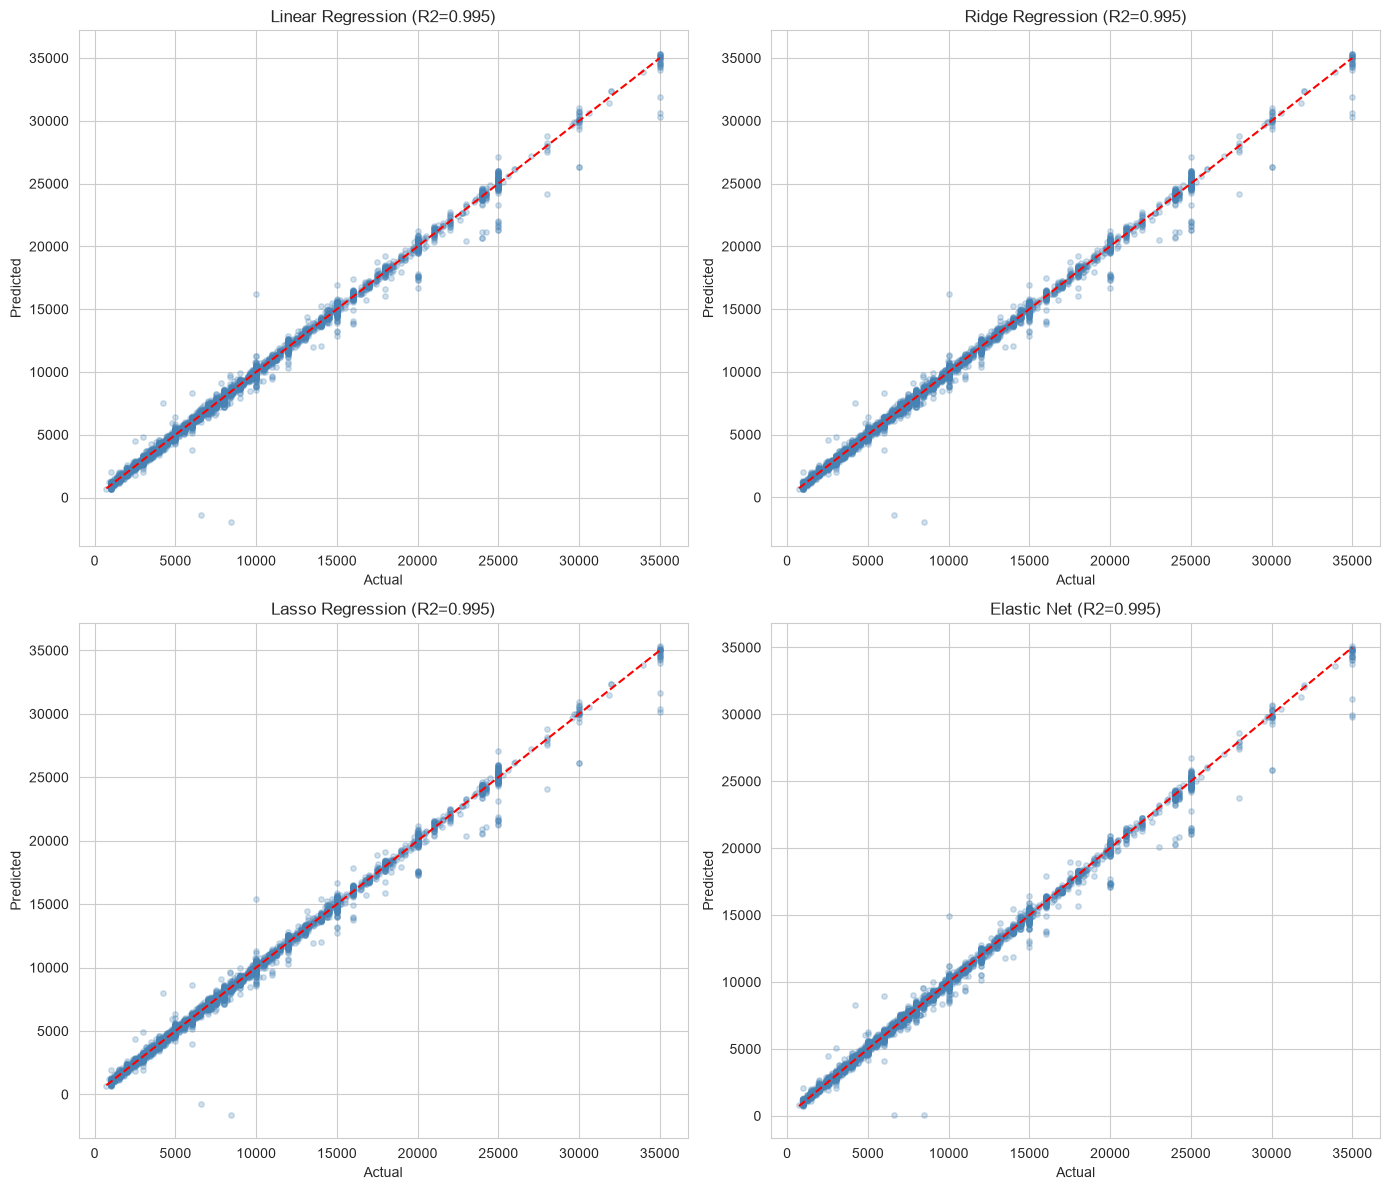

In [ ]:
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net']
test_preds = [y_test_pred_lr, y_test_pred_ridge, y_test_pred_lasso, y_test_pred_en]
test_r2s = [lr_test_r2, ridge_test_r2, lasso_test_r2, en_test_r2]

fig, axes = plt.subplots(2, 2, figsize=(14,12))
axes = axes.flatten()
for i in range(4):
    axes[i].scatter(y_test, test_preds[i], alpha=0.25, color='steelblue', s=15)
    lims = [y_test.min(), y_test.max()]
    axes[i].plot(lims, lims, 'r--')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{models[i]} (R2={test_r2s[i]:.3f})')
plt.tight_layout()
plt.show()

### Residual Plot
Checks whether prediction errors are randomly scattered around zero.

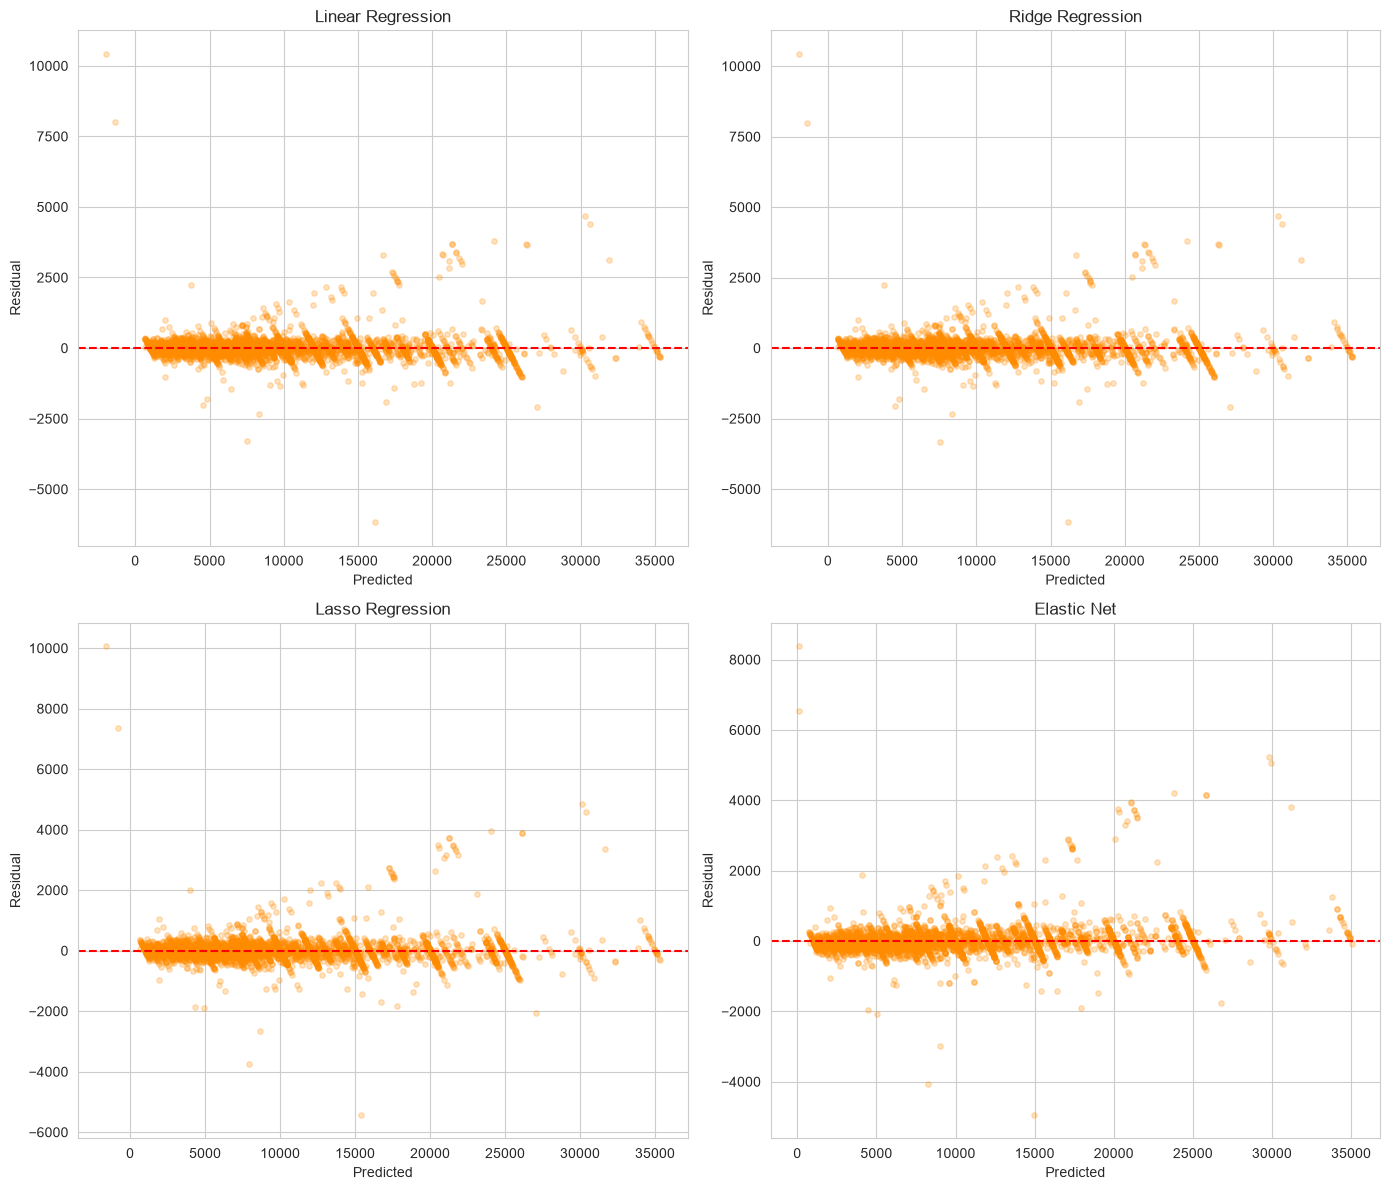

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,12))
axes = axes.flatten()
for i in range(4):
    resid = y_test.values - test_preds[i]
    axes[i].scatter(test_preds[i], resid, alpha=0.25, color='darkorange', s=15)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')
    axes[i].set_title(models[i])
plt.tight_layout()
plt.show()

### Training vs Validation Error
Compares train and validation RMSE/R2 to check for overfitting.

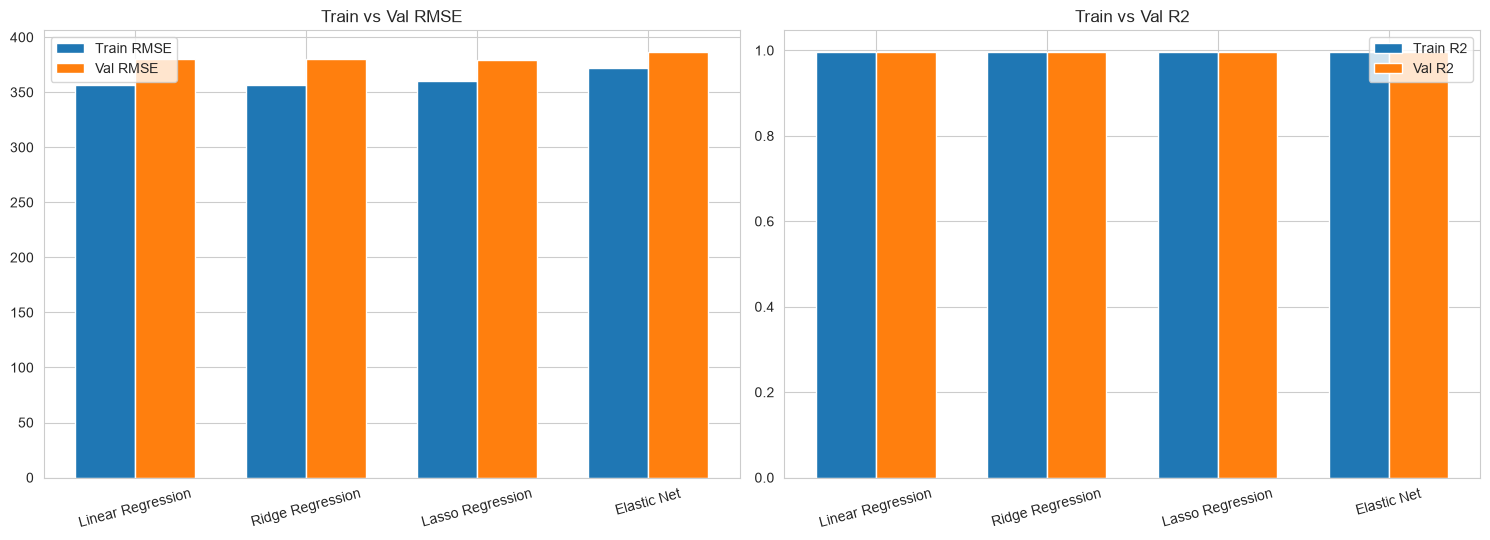

In [ ]:
train_rmse_list = [lr_train_rmse, ridge_train_rmse, lasso_train_rmse, en_train_rmse]
val_rmse_list = [lr_val_rmse, ridge_val_rmse, lasso_val_rmse, en_val_rmse]
train_r2_list = [lr_train_r2, ridge_train_r2, lasso_train_r2, en_train_r2]
val_r2_list = [lr_val_r2, ridge_val_r2, lasso_val_r2, en_val_r2]

x = np.arange(4)
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15,5.5))

axes[0].bar(x - w/2, train_rmse_list, w, label='Train RMSE')
axes[0].bar(x + w/2, val_rmse_list, w, label='Val RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].legend()
axes[0].set_title('Train vs Val RMSE')

axes[1].bar(x - w/2, train_r2_list, w, label='Train R2')
axes[1].bar(x + w/2, val_r2_list, w, label='Val R2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].legend()
axes[1].set_title('Train vs Val R2')

plt.tight_layout()
plt.show()

### Coefficient Bar Chart
Top 15 features by absolute Linear coefficient, compared across all four models.

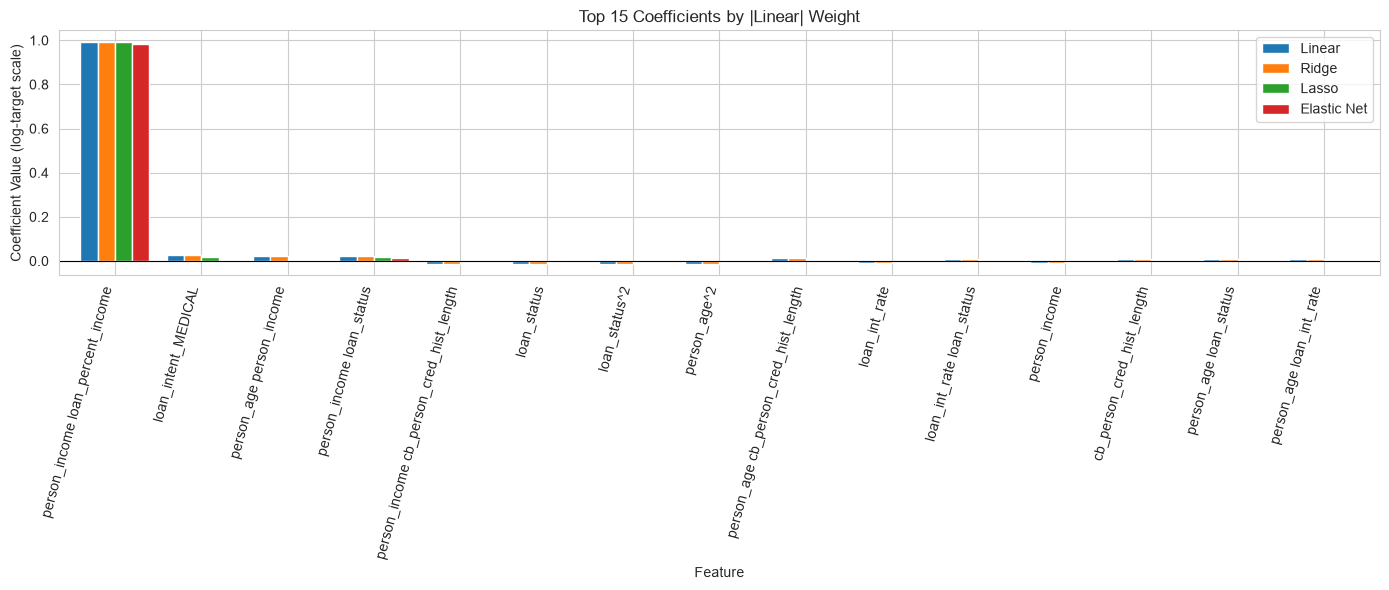

In [ ]:
top_feats = table4.reindex(table4['Linear'].abs().sort_values(ascending=False).index).head(15)
top_feats.set_index('Feature').plot(kind='bar', figsize=(14,6), width=0.8)
plt.ylabel('Coefficient Value (log-target scale)')
plt.title('Top 15 Coefficients by |Linear| Weight')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

### Best Model Comparison
Which model has the highest R2 and which has the lowest MAE.

In [ ]:
r2_scores = {'Linear Regression': lr_test_r2, 'Ridge Regression': ridge_test_r2,
             'Lasso Regression': lasso_test_r2, 'Elastic Net': en_test_r2}
mae_scores = {'Linear Regression': lr_test_mae, 'Ridge Regression': ridge_test_mae,
              'Lasso Regression': lasso_test_mae, 'Elastic Net': en_test_mae}

best_model_r2 = max(r2_scores, key=r2_scores.get)
best_model_mae = min(mae_scores, key=mae_scores.get)

print('highest R2:', best_model_r2, r2_scores[best_model_r2])
print('lowest MAE:', best_model_mae, mae_scores[best_model_mae])

highest R2: Lasso Regression 0.9954932646044816
lowest MAE: Lasso Regression 204.02550903817283


### Overfitting Check Table
Numeric train-vs-validation RMSE/R2 gap for every model.

In [ ]:
table5 = pd.DataFrame({
    'Model': models,
    'Train RMSE': train_rmse_list,
    'Val RMSE': val_rmse_list,
    'RMSE Gap': [v - t for v, t in zip(val_rmse_list, train_rmse_list)],
    'Train R2': train_r2_list,
    'Val R2': val_r2_list,
    'R2 Gap': [t - v for t, v in zip(train_r2_list, val_r2_list)]
}).round(4)
table5

,Model,Train RMSE,Val RMSE,RMSE Gap,Train R2,Val R2,R2 Gap
0,Linear Regression,356.6473,380.5189,23.8716,0.9968,0.9964,0.0004
1,Ridge Regression,356.6479,380.5203,23.8725,0.9968,0.9964,0.0004
2,Lasso Regression,359.8434,379.3801,19.5367,0.9968,0.9964,0.0003
3,Elastic Net,372.3021,386.7686,14.4665,0.9965,0.9963,0.0002


### Final Summary
One-line comparison of train/val/test R2 and training time for all four models.

In [ ]:
print('Model'.ljust(20), 'Train R2', 'Val R2', 'Test R2', 'Time')
print('LinearRegression'.ljust(20), round(lr_train_r2,4), round(lr_val_r2,4), round(lr_test_r2,4), round(lr_time,3))
print('Ridge'.ljust(20), round(ridge_train_r2,4), round(ridge_val_r2,4), round(ridge_test_r2,4), round(ridge_time,3))
print('Lasso'.ljust(20), round(lasso_train_r2,4), round(lasso_val_r2,4), round(lasso_test_r2,4), round(lasso_time,3))
print('ElasticNet'.ljust(20), round(en_train_r2,4), round(en_val_r2,4), round(en_test_r2,4), round(en_time,3))


Model                Train R2 Val R2 Test R2 Time
LinearRegression     0.9968 0.9964 0.9954 0.215
Ridge                0.9968 0.9964 0.9954 11.484
Lasso                0.9968 0.9964 0.9955 2.596
ElasticNet           0.9965 0.9963 0.9955 22.913
